<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/07_Working_with_Text_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Bekerja dengan Data Teks

**Referensi:** Introduction to Machine Learning with Python -- Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Data teks adalah salah satu jenis data yang paling umum ditemukan di dunia nyata.
Namun algoritma ML tidak bisa langsung memproses teks -- teks harus diubah
terlebih dahulu menjadi representasi numerik.

Chapter ini membahas teknik-teknik untuk mengubah teks menjadi fitur numerik
yang bisa digunakan oleh algoritma ML standar.

**Topik yang dibahas:**
- Representasi Bag-of-Words dengan CountVectorizer
- tf-idf (Term Frequency -- Inverse Document Frequency)
- Stopwords dan min/max document frequency
- n-Grams (bigram, trigram)
- Tokenisasi lanjutan
- Topic Modeling dengan Latent Dirichlet Allocation (LDA)


## 7.0 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Library berhasil diimport.")


Library berhasil diimport.


## 7.1 Jenis Data Teks dalam Machine Learning

Data teks muncul dalam berbagai bentuk:

**String kategorikal (bukan teks bebas)**
Contoh: nama negara, nama produk, kode kategori.
Cara penanganan: One-Hot Encoding atau Ordinal Encoding seperti Chapter 4.

**Teks bebas (free text)**
Contoh: ulasan produk, tweet, artikel berita, email, komentar.
Cara penanganan: teknik NLP (Natural Language Processing) yang dibahas di chapter ini.

### Tantangan Data Teks

- Panjang dokumen bervariasi: dari satu kalimat hingga ribuan halaman
- Kosakata sangat besar: bahasa Inggris punya lebih dari 170.000 kata
- Makna bergantung pada konteks dan urutan kata
- Bahasa manusia ambigu dan tidak konsisten

### Pendekatan Bag-of-Words

Pendekatan paling sederhana dan sering sangat efektif:
representasikan dokumen sebagai "kantong kata" tanpa memperhatikan urutan.

Setiap dokumen direpresentasikan sebagai vektor hitungan kata,
di mana setiap elemen mencerminkan berapa kali kata tertentu muncul.


In [2]:
# Contoh sederhana: representasi teks sebagai fitur
sample_texts = [
    "Machine learning sangat menarik",
    "Python adalah bahasa terbaik untuk machine learning",
    "Saya suka belajar Python dan machine learning",
    "Deep learning adalah cabang dari machine learning",
    "Natural language processing menggunakan machine learning",
]

print("Contoh dokumen teks:")
for i, text in enumerate(sample_texts):
    print(f"  [{i}] {text}")
print()

# CountVectorizer mengubah teks menjadi matriks hitungan kata
vect = CountVectorizer()
X_bow = vect.fit_transform(sample_texts)

print(f"Jumlah dokumen   : {X_bow.shape[0]}")
print(f"Ukuran vocabulary: {X_bow.shape[1]}")
print(f"Vocabulary       : {sorted(vect.vocabulary_.keys())}")
print()

# Tampilkan matriks sebagai DataFrame
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=sorted(vect.vocabulary_.keys())
)
print("Matriks Bag-of-Words (baris=dokumen, kolom=kata):")
print(df_bow.to_string())


Contoh dokumen teks:
  [0] Machine learning sangat menarik
  [1] Python adalah bahasa terbaik untuk machine learning
  [2] Saya suka belajar Python dan machine learning
  [3] Deep learning adalah cabang dari machine learning
  [4] Natural language processing menggunakan machine learning

Jumlah dokumen   : 5
Ukuran vocabulary: 20
Vocabulary       : ['adalah', 'bahasa', 'belajar', 'cabang', 'dan', 'dari', 'deep', 'language', 'learning', 'machine', 'menarik', 'menggunakan', 'natural', 'processing', 'python', 'sangat', 'saya', 'suka', 'terbaik', 'untuk']

Matriks Bag-of-Words (baris=dokumen, kolom=kata):
   adalah  bahasa  belajar  cabang  dan  dari  deep  language  learning  machine  menarik  menggunakan  natural  processing  python  sangat  saya  suka  terbaik  untuk
0       0       0        0       0    0     0     0         0         1        1        1            0        0           0       0       1     0     0        0      0
1       1       1        0       0    0     0     0    

## 7.2 Dataset: Analisis Sentimen Ulasan Film

Untuk demonstrasi, kita buat dataset ulasan film sintetis yang mencerminkan
struktur dataset sentimen nyata (seperti IMDb).

Dataset ini terdiri dari ulasan positif dan negatif dengan label biner:
- 1 = ulasan positif
- 0 = ulasan negatif

Tujuan: membangun classifier yang bisa memprediksi sentimen ulasan baru.


In [3]:
# Buat dataset ulasan film sintetis
positive_reviews = [
    "Film ini sangat bagus dan menghibur sekali",
    "Akting pemainnya luar biasa dan cerita sangat menarik",
    "Saya sangat menyukai film ini dari awal hingga akhir",
    "Sutradara berhasil membuat film yang indah dan berkesan",
    "Cerita yang kuat dengan karakter yang sangat memorable",
    "Visual efek yang menakjubkan dan musik yang indah",
    "Film terbaik yang pernah saya tonton tahun ini",
    "Sangat direkomendasikan untuk semua kalangan penonton",
    "Plot yang cerdas dan dialog yang tajam dan mengena",
    "Performa akting yang memukau dari seluruh cast",
    "Film yang sangat emosional dan menyentuh hati",
    "Penggarapan yang sangat detail dan teliti sekali",
    "Salah satu film terbaik dekade ini tanpa diragukan",
    "Cerita orisinal yang segar dan tidak membosankan",
    "Ending yang memuaskan dan tidak terduga sama sekali",
    "Sinematografi yang cantik dan memanjakan mata",
    "Karakter yang kompleks dan berkembang dengan baik",
    "Film yang sangat layak ditonton berkali-kali",
    "Humor yang tepat sasaran tanpa terasa dipaksakan",
    "Kombinasi sempurna antara aksi dan drama yang memikat",
]

negative_reviews = [
    "Film ini membosankan dan tidak menarik sama sekali",
    "Akting pemainnya sangat buruk dan cerita tidak logis",
    "Saya menyesal menonton film yang sangat mengecewakan ini",
    "Sutradara gagal total membuat film yang layak ditonton",
    "Cerita yang lemah dengan karakter yang sangat datar",
    "Visual efek yang murahan dan musik yang mengganggu",
    "Film terburuk yang pernah saya tonton sepanjang hidup",
    "Tidak ada yang bisa direkomendasikan dari film ini",
    "Plot yang membingungkan dan dialog yang sangat kaku",
    "Performa akting yang sangat mengecewakan dari semua cast",
    "Film yang sangat membosankan dan membuang waktu saja",
    "Penggarapan yang sangat buruk dan tidak profesional",
    "Salah satu film terburuk yang pernah dibuat manusia",
    "Cerita yang sangat klise dan sudah bisa ditebak semua",
    "Ending yang sangat mengecewakan dan tidak memuaskan",
    "Sinematografi yang buruk dan membuat pusing kepala",
    "Karakter yang sangat datar dan tidak berkembang",
    "Film yang tidak layak ditonton apalagi diulang lagi",
    "Humor yang sangat dipaksakan dan tidak lucu sama sekali",
    "Kombinasi yang buruk antara aksi dan drama yang gagal",
]

reviews = positive_reviews + negative_reviews
labels  = np.array([1]*20 + [0]*20)

print(f"Total dokumen    : {len(reviews)}")
print(f"Ulasan positif   : {labels.sum()}")
print(f"Ulasan negatif   : {(labels==0).sum()}")
print()
print("Contoh ulasan positif:", positive_reviews[0])
print("Contoh ulasan negatif:", negative_reviews[0])

X_text_tr, X_text_te, y_text_tr, y_text_te = train_test_split(
    reviews, labels, test_size=0.25, random_state=42, stratify=labels)
print()
print(f"Training set: {len(X_text_tr)} ulasan")
print(f"Test set    : {len(X_text_te)} ulasan")


Total dokumen    : 40
Ulasan positif   : 20
Ulasan negatif   : 20

Contoh ulasan positif: Film ini sangat bagus dan menghibur sekali
Contoh ulasan negatif: Film ini membosankan dan tidak menarik sama sekali

Training set: 30 ulasan
Test set    : 10 ulasan


## 7.3 CountVectorizer: Bag-of-Words

CountVectorizer mengimplementasikan representasi Bag-of-Words.

**Tiga langkah utama:**

1. **Tokenisasi**: memecah teks menjadi token (kata-kata).
   Defaultnya memisahkan berdasarkan spasi dan tanda baca,
   dan mengubah semua huruf menjadi lowercase.

2. **Membangun vocabulary**: mengumpulkan semua token unik dari
   seluruh corpus (kumpulan dokumen).

3. **Encoding**: untuk setiap dokumen, menghitung berapa kali
   setiap kata dalam vocabulary muncul.

**Parameter penting CountVectorizer:**
- `min_df`: abaikan kata yang muncul di kurang dari n dokumen (atau proporsi)
- `max_df`: abaikan kata yang muncul di lebih dari n dokumen (terlalu umum)
- `max_features`: batasi ukuran vocabulary ke n kata terbanyak
- `ngram_range`: tentukan apakah pakai unigram, bigram, dll
- `stop_words`: daftar kata yang diabaikan


In [4]:
# CountVectorizer pada dataset ulasan
vect_cv = CountVectorizer()
X_tr_cv = vect_cv.fit_transform(X_text_tr)
X_te_cv = vect_cv.transform(X_text_te)

print("=== CountVectorizer pada Dataset Ulasan ===")
print(f"Ukuran vocabulary        : {len(vect_cv.vocabulary_)}")
print(f"Shape matriks training   : {X_tr_cv.shape}")
print(f"Tipe matriks (sparse)    : {type(X_tr_cv)}")
print(f"Elemen non-zero          : {X_tr_cv.nnz}")
print(f"Sparsity                 : {1 - X_tr_cv.nnz / (X_tr_cv.shape[0] * X_tr_cv.shape[1]):.2%}")
print()

# Klasifikasi dengan Logistic Regression
lr_cv = LogisticRegression(max_iter=5000, C=1)
lr_cv.fit(X_tr_cv, y_text_tr)
print(f"Training accuracy: {lr_cv.score(X_tr_cv, y_text_tr):.4f}")
print(f"Test accuracy    : {lr_cv.score(X_te_cv, y_text_te):.4f}")


=== CountVectorizer pada Dataset Ulasan ===
Ukuran vocabulary        : 105
Shape matriks training   : (30, 105)
Tipe matriks (sparse)    : <class 'scipy.sparse._csr.csr_matrix'>
Elemen non-zero          : 226
Sparsity                 : 92.83%

Training accuracy: 1.0000
Test accuracy    : 0.2000


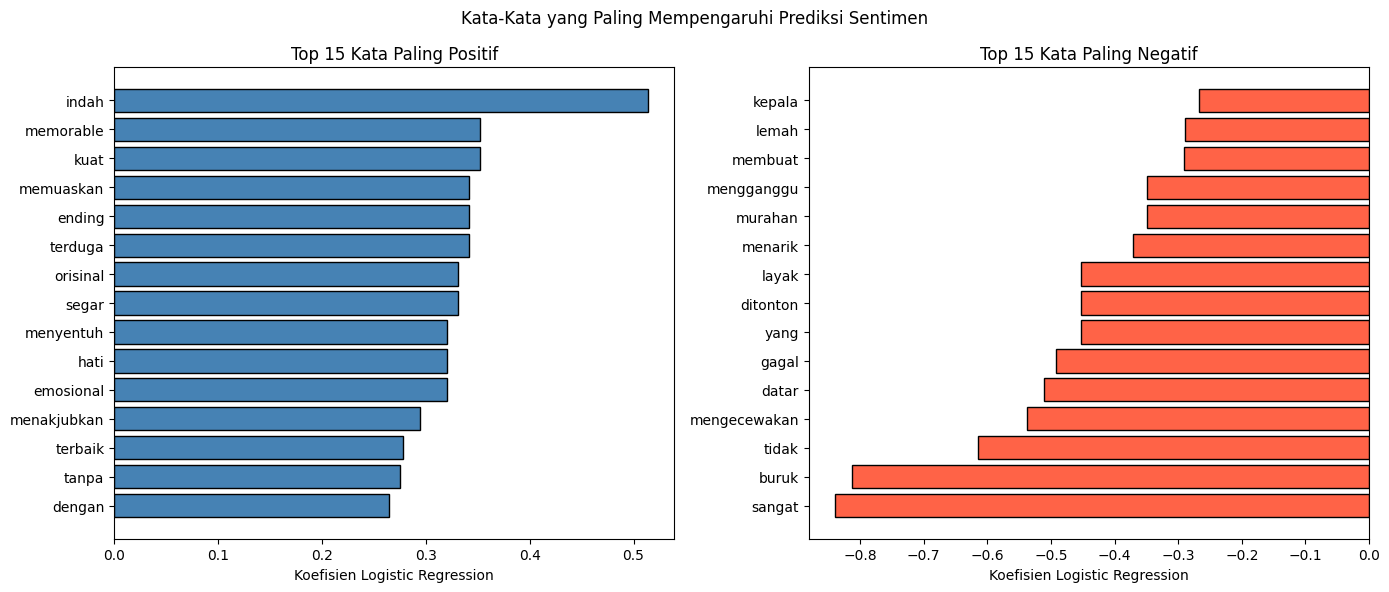

In [5]:
# Kata-kata yang paling berpengaruh menurut Logistic Regression
feature_names = np.array(vect_cv.get_feature_names_out())
coef = lr_cv.coef_[0]

top_pos_idx = np.argsort(coef)[-15:]
top_neg_idx = np.argsort(coef)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_pos_idx], coef[top_pos_idx],
             color="steelblue", edgecolor="black")
axes[0].set_title("Top 15 Kata Paling Positif")
axes[0].set_xlabel("Koefisien Logistic Regression")

axes[1].barh(feature_names[top_neg_idx], coef[top_neg_idx],
             color="tomato", edgecolor="black")
axes[1].set_title("Top 15 Kata Paling Negatif")
axes[1].set_xlabel("Koefisien Logistic Regression")

plt.suptitle("Kata-Kata yang Paling Mempengaruhi Prediksi Sentimen", fontsize=12)
plt.tight_layout()
plt.show()


In [6]:
# Pengaruh min_df dan max_features
print("Pengaruh parameter CountVectorizer:")
print(f"{'Konfigurasi':<35} {'Vocab':>8} {'Test Acc':>10}")
print("-" * 56)

configs = [
    ("default",                          CountVectorizer()),
    ("min_df=2",                         CountVectorizer(min_df=2)),
    ("max_features=50",                  CountVectorizer(max_features=50)),
    ("min_df=2, max_features=50",        CountVectorizer(min_df=2, max_features=50)),
]

for name, cv_obj in configs:
    X_tr_tmp = cv_obj.fit_transform(X_text_tr)
    X_te_tmp = cv_obj.transform(X_text_te)
    lr_tmp = LogisticRegression(max_iter=5000, C=1)
    lr_tmp.fit(X_tr_tmp, y_text_tr)
    vocab_size = len(cv_obj.vocabulary_)
    test_acc   = lr_tmp.score(X_te_tmp, y_text_te)
    print(f"{name:<35} {vocab_size:>8} {test_acc:>10.4f}")


Pengaruh parameter CountVectorizer:
Konfigurasi                            Vocab   Test Acc
--------------------------------------------------------
default                                  105     0.2000
min_df=2                                  40     0.5000
max_features=50                           50     0.4000
min_df=2, max_features=50                 40     0.5000


## 7.4 Stopwords

Stopwords adalah kata-kata yang sangat umum dan tidak membawa
informasi semantik yang bermakna: "the", "is", "and", "a", "in", dll.

Menghapus stopwords dapat:
- Mengurangi ukuran vocabulary secara signifikan
- Mengurangi noise dalam representasi
- Mempercepat training

scikit-learn menyediakan daftar stopwords bahasa Inggris bawaan.
Untuk bahasa lain (termasuk Indonesia), kita perlu menyediakan sendiri.

**Catatan:** menghapus stopwords tidak selalu meningkatkan performa.
Pada beberapa kasus (seperti analisis sentimen), kata seperti "not" sangat penting.
Selalu evaluasi dengan dan tanpa stopwords.


In [7]:
# Contoh stopwords bahasa Inggris
print(f"Jumlah stopwords bawaan sklearn: {len(ENGLISH_STOP_WORDS)}")
print()
print("20 stopwords pertama:")
print(sorted(list(ENGLISH_STOP_WORDS))[:20])
print()

# Stopwords sederhana bahasa Indonesia (contoh)
stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan",
    "untuk", "pada", "adalah", "ada", "dalam", "juga", "sangat",
    "lebih", "akan", "tidak", "bisa", "saya", "anda", "kita",
    "mereka", "kami", "sudah", "belum", "pernah", "semua", "saja"
}
print(f"Contoh stopwords Indonesia (custom): {len(stopwords_id)} kata")
print(sorted(stopwords_id)[:15])


Jumlah stopwords bawaan sklearn: 318

20 stopwords pertama:
['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst']

Contoh stopwords Indonesia (custom): 29 kata
['ada', 'adalah', 'akan', 'anda', 'belum', 'bisa', 'dalam', 'dan', 'dari', 'dengan', 'di', 'ini', 'itu', 'juga', 'kami']


In [8]:
# Perbandingan dengan dan tanpa stopwords Indonesia
print("Perbandingan stopwords pada dataset ulasan (Bahasa Indonesia):")
print(f"{'Konfigurasi':<35} {'Vocab':>8} {'Test Acc':>10}")
print("-" * 56)

configs_sw = [
    ("Tanpa stopwords",       CountVectorizer()),
    ("Dengan stopwords ID",   CountVectorizer(stop_words=list(stopwords_id))),
    ("min_df=2, stop ID",     CountVectorizer(min_df=2, stop_words=list(stopwords_id))),
]

for name, cv_obj in configs_sw:
    X_tr_tmp = cv_obj.fit_transform(X_text_tr)
    X_te_tmp = cv_obj.transform(X_text_te)
    lr_tmp = LogisticRegression(max_iter=5000, C=1)
    lr_tmp.fit(X_tr_tmp, y_text_tr)
    vocab_size = len(cv_obj.vocabulary_)
    test_acc   = lr_tmp.score(X_te_tmp, y_text_te)
    print(f"{name:<35} {vocab_size:>8} {test_acc:>10.4f}")


Perbandingan stopwords pada dataset ulasan (Bahasa Indonesia):
Konfigurasi                            Vocab   Test Acc
--------------------------------------------------------
Tanpa stopwords                          105     0.2000
Dengan stopwords ID                       92     0.0000
min_df=2, stop ID                         31     0.4000


## 7.5 tf-idf: Term Frequency -- Inverse Document Frequency

Bag-of-Words memberikan bobot yang sama pada semua kata berdasarkan frekuensinya.
Namun kata yang muncul di semua dokumen (seperti "the" atau "adalah")
seharusnya mendapat bobot lebih rendah karena tidak diskriminatif.

tf-idf mengatasi ini dengan mengalikan dua komponen:

**tf (Term Frequency)**
Seberapa sering kata muncul dalam dokumen ini.
tf(t, d) = jumlah kemunculan kata t dalam dokumen d

**idf (Inverse Document Frequency)**
Seberapa jarang kata muncul di seluruh corpus.
Kata yang muncul di banyak dokumen mendapat nilai idf rendah.

    idf(t) = log((1 + N) / (1 + df(t))) + 1

di mana N = jumlah dokumen, df(t) = jumlah dokumen yang mengandung kata t.

**Formula tf-idf:**

    tfidf(t, d) = tf(t, d) * idf(t)

**Intuisi:**
- Kata yang sering muncul di dokumen ini tapi jarang di dokumen lain: skor tinggi
- Kata yang muncul di hampir semua dokumen: skor rendah
- Kata yang tidak pernah muncul: skor 0

Setelah dihitung, setiap dokumen biasanya dinormalisasi ke panjang unit (L2 norm).


In [9]:
# Demonstrasi tf-idf secara manual
sample_corpus = [
    "kucing makan ikan",
    "anjing makan daging",
    "kucing dan anjing adalah hewan peliharaan",
]

tfidf_demo = TfidfVectorizer()
X_tfidf_demo = tfidf_demo.fit_transform(sample_corpus)

print("=== Demonstrasi tf-idf ===")
print("Corpus:")
for i, doc in enumerate(sample_corpus):
    print(f"  [{i}]: {doc}")
print()

df_tfidf_demo = pd.DataFrame(
    X_tfidf_demo.toarray().round(4),
    columns=tfidf_demo.get_feature_names_out()
)
print("Matriks tf-idf:")
print(df_tfidf_demo.to_string())
print()
print("Perhatikan: 'makan' muncul di 2 dari 3 dokumen sehingga idf-nya lebih rendah")
print("dari 'kucing' atau 'anjing' yang tidak muncul di semua dokumen.")


=== Demonstrasi tf-idf ===
Corpus:
  [0]: kucing makan ikan
  [1]: anjing makan daging
  [2]: kucing dan anjing adalah hewan peliharaan

Matriks tf-idf:
   adalah  anjing  daging     dan   hewan    ikan  kucing   makan  peliharaan
0  0.0000  0.0000  0.0000  0.0000  0.0000  0.6809  0.5179  0.5179      0.0000
1  0.0000  0.5179  0.6809  0.0000  0.0000  0.0000  0.0000  0.5179      0.0000
2  0.4404  0.3349  0.0000  0.4404  0.4404  0.0000  0.3349  0.0000      0.4404

Perhatikan: 'makan' muncul di 2 dari 3 dokumen sehingga idf-nya lebih rendah
dari 'kucing' atau 'anjing' yang tidak muncul di semua dokumen.


In [10]:
# TfidfVectorizer pada dataset ulasan
tfidf_vect = TfidfVectorizer(sublinear_tf=True, min_df=1)
X_tr_tfidf = tfidf_vect.fit_transform(X_text_tr)
X_te_tfidf = tfidf_vect.transform(X_text_te)

lr_tfidf = LogisticRegression(max_iter=5000, C=1)
lr_tfidf.fit(X_tr_tfidf, y_text_tr)

print("=== TfidfVectorizer pada Dataset Ulasan ===")
print(f"Ukuran vocabulary  : {len(tfidf_vect.vocabulary_)}")
print(f"Training accuracy  : {lr_tfidf.score(X_tr_tfidf, y_text_tr):.4f}")
print(f"Test accuracy      : {lr_tfidf.score(X_te_tfidf, y_text_te):.4f}")
print()

# Perbandingan CountVectorizer vs TfidfVectorizer
print("Perbandingan CountVectorizer vs TfidfVectorizer:")
print(f"{'Vectorizer':<30} {'Test Accuracy':>15}")
print("-" * 47)

for name, vec in [("CountVectorizer", CountVectorizer()),
                   ("TfidfVectorizer", TfidfVectorizer(sublinear_tf=True)),
                   ("Tfidf + min_df=2", TfidfVectorizer(sublinear_tf=True, min_df=2))]:
    X_tr_v = vec.fit_transform(X_text_tr)
    X_te_v = vec.transform(X_text_te)
    lr_v = LogisticRegression(max_iter=5000, C=1).fit(X_tr_v, y_text_tr)
    print(f"{name:<30} {lr_v.score(X_te_v, y_text_te):>15.4f}")


=== TfidfVectorizer pada Dataset Ulasan ===
Ukuran vocabulary  : 105
Training accuracy  : 1.0000
Test accuracy      : 0.2000

Perbandingan CountVectorizer vs TfidfVectorizer:
Vectorizer                       Test Accuracy
-----------------------------------------------
CountVectorizer                         0.2000
TfidfVectorizer                         0.2000
Tfidf + min_df=2                        0.3000


In [11]:
# Kata-kata dengan bobot tf-idf tertinggi per dokumen
feature_names_tfidf = tfidf_vect.get_feature_names_out()

print("Kata dengan bobot tf-idf tertinggi per dokumen (5 training pertama):")
print()
for i in range(min(5, len(X_text_tr))):
    doc_vector = X_tr_tfidf[i].toarray()[0]
    top_indices = np.argsort(doc_vector)[-5:][::-1]
    top_words = [(feature_names_tfidf[j], doc_vector[j]) for j in top_indices if doc_vector[j] > 0]
    label = "Positif" if y_text_tr[i] == 1 else "Negatif"
    print(f"  Dokumen {i} ({label}):")
    print(f"  Teks: {X_text_tr[i][:60]}...")
    for word, score in top_words:
        print(f"    '{word}': {score:.4f}")
    print()


Kata dengan bobot tf-idf tertinggi per dokumen (5 training pertama):

  Dokumen 0 (Positif):
  Teks: Saya sangat menyukai film ini dari awal hingga akhir...
    'menyukai': 0.3959
    'awal': 0.3959
    'akhir': 0.3959
    'hingga': 0.3959
    'saya': 0.3225

  Dokumen 1 (Positif):
  Teks: Kombinasi sempurna antara aksi dan drama yang memikat...
    'sempurna': 0.4289
    'memikat': 0.4289
    'drama': 0.3824
    'kombinasi': 0.3824
    'antara': 0.3824

  Dokumen 2 (Negatif):
  Teks: Plot yang membingungkan dan dialog yang sangat kaku...
    'plot': 0.4626
    'kaku': 0.4626
    'dialog': 0.4626
    'membingungkan': 0.4626
    'yang': 0.2462

  Dokumen 3 (Positif):
  Teks: Sangat direkomendasikan untuk semua kalangan penonton...
    'untuk': 0.4520
    'penonton': 0.4520
    'kalangan': 0.4520
    'direkomendasikan': 0.4520
    'semua': 0.3683

  Dokumen 4 (Negatif):
  Teks: Karakter yang sangat datar dan tidak berkembang...
    'berkembang': 0.5143
    'datar': 0.5143
    'karakter':

## 7.6 n-Grams

Bag-of-Words kehilangan informasi urutan kata. Frasa seperti
"tidak bagus" dan "sangat bagus" akan terlihat mirip karena
mengandung kata-kata yang sama.

n-Grams menangkap urutan n kata berturut-turut:
- **Unigram (n=1)**: satu kata -- "tidak", "bagus"
- **Bigram (n=2)**: dua kata berurutan -- "tidak bagus", "sangat bagus"
- **Trigram (n=3)**: tiga kata berurutan -- "tidak begitu bagus"

**Parameter ngram_range=(min_n, max_n)**
Menggunakan semua n-gram dari min_n hingga max_n.

Contoh: `ngram_range=(1, 2)` menggunakan unigram DAN bigram sekaligus.

**Trade-off n-Grams:**
- Menangkap lebih banyak konteks dan makna
- Vocabulary jauh lebih besar (bigram bisa 10-100x lebih besar dari unigram)
- Risiko data lebih sparse
- Training lebih lambat


In [12]:
# Demonstrasi n-grams
demo_texts = [
    "Film ini tidak bagus sama sekali",
    "Film ini sangat bagus sekali",
    "Film ini biasa saja tidak istimewa",
]

print("=== Demonstrasi n-Grams ===")
print("Corpus:")
for t in demo_texts:
    print(f"  {t}")
print()

for ngram_range in [(1,1), (2,2), (1,2)]:
    vect_ng = CountVectorizer(ngram_range=ngram_range)
    X_ng = vect_ng.fit_transform(demo_texts)
    print(f"ngram_range={ngram_range}: {len(vect_ng.vocabulary_)} fitur")
    print(f"  Features: {sorted(vect_ng.vocabulary_.keys())}")
    print()


=== Demonstrasi n-Grams ===
Corpus:
  Film ini tidak bagus sama sekali
  Film ini sangat bagus sekali
  Film ini biasa saja tidak istimewa

ngram_range=(1, 1): 10 fitur
  Features: ['bagus', 'biasa', 'film', 'ini', 'istimewa', 'saja', 'sama', 'sangat', 'sekali', 'tidak']

ngram_range=(2, 2): 12 fitur
  Features: ['bagus sama', 'bagus sekali', 'biasa saja', 'film ini', 'ini biasa', 'ini sangat', 'ini tidak', 'saja tidak', 'sama sekali', 'sangat bagus', 'tidak bagus', 'tidak istimewa']

ngram_range=(1, 2): 22 fitur
  Features: ['bagus', 'bagus sama', 'bagus sekali', 'biasa', 'biasa saja', 'film', 'film ini', 'ini', 'ini biasa', 'ini sangat', 'ini tidak', 'istimewa', 'saja', 'saja tidak', 'sama', 'sama sekali', 'sangat', 'sangat bagus', 'sekali', 'tidak', 'tidak bagus', 'tidak istimewa']



In [13]:
# Pengaruh ngram_range pada performa klasifikasi
print("Pengaruh ngram_range pada Analisis Sentimen:")
print(f"{'ngram_range':<20} {'Vocab':>8} {'Test Acc':>12}")
print("-" * 43)

for ngram in [(1,1), (1,2), (1,3), (2,2), (2,3)]:
    vec = TfidfVectorizer(ngram_range=ngram, min_df=1, sublinear_tf=True)
    X_tr_ng = vec.fit_transform(X_text_tr)
    X_te_ng = vec.transform(X_text_te)
    lr_ng = LogisticRegression(max_iter=5000, C=1).fit(X_tr_ng, y_text_tr)
    print(f"{str(ngram):<20} {len(vec.vocabulary_):>8} {lr_ng.score(X_te_ng, y_text_te):>12.4f}")

print()
print("Bigram (1,2) biasanya memberikan peningkatan atas unigram saja.")
print("Trigram (1,3) kadang membantu tapi juga meningkatkan risiko overfitting.")


Pengaruh ngram_range pada Analisis Sentimen:
ngram_range             Vocab     Test Acc
-------------------------------------------
(1, 1)                    105       0.2000
(1, 2)                    258       0.2000
(1, 3)                    416       0.2000
(2, 2)                    153       0.3000
(2, 3)                    311       0.3000

Bigram (1,2) biasanya memberikan peningkatan atas unigram saja.
Trigram (1,3) kadang membantu tapi juga meningkatkan risiko overfitting.


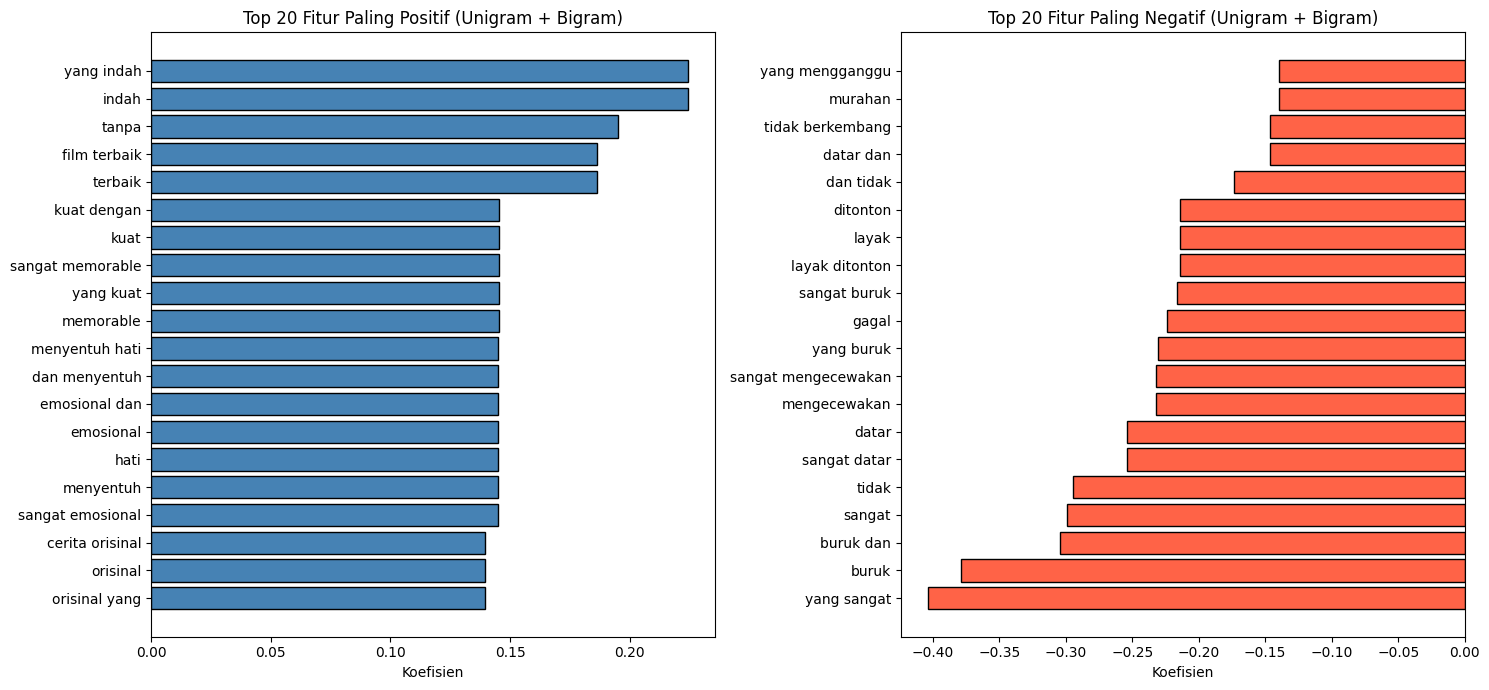

Test accuracy dengan bigram: 0.2000


In [16]:
# Contoh bigram yang informatif untuk sentimen
vec_bi = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
X_tr_bi = vec_bi.fit_transform(X_text_tr)
X_te_bi = vec_bi.transform(X_text_te)

lr_bi = LogisticRegression(max_iter=5000, C=1)
lr_bi.fit(X_tr_bi, y_text_tr)

feature_names_bi = np.array(vec_bi.get_feature_names_out())
coef_bi = lr_bi.coef_[0]

top_pos = np.argsort(coef_bi)[-20:]
top_neg = np.argsort(coef_bi)[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(feature_names_bi[top_pos], coef_bi[top_pos],
             color="steelblue", edgecolor="black")
axes[0].set_title("Top 20 Fitur Paling Positif (Unigram + Bigram)")
axes[0].set_xlabel("Koefisien")

axes[1].barh(feature_names_bi[top_neg], coef_bi[top_neg],
             color="tomato", edgecolor="black")
axes[1].set_title("Top 20 Fitur Paling Negatif (Unigram + Bigram)")
axes[1].set_xlabel("Koefisien")

plt.tight_layout()
plt.show()
print(f"Test accuracy dengan bigram: {lr_bi.score(X_te_bi, y_text_te):.4f}")


## 7.7 Pipeline dan GridSearchCV untuk Teks

Pipeline sangat cocok untuk klasifikasi teks karena menghubungkan
vectorizer (yang harus di-fit hanya pada training data) dengan classifier.

GridSearchCV memungkinkan kita mencari kombinasi parameter terbaik
dari vectorizer DAN classifier secara bersamaan.


In [17]:
# Pipeline teks: TfidfVectorizer + LogisticRegression
text_pipe = make_pipeline(
    TfidfVectorizer(sublinear_tf=True),
    LogisticRegression(max_iter=5000)
)

# Grid search atas parameter vectorizer dan classifier
param_grid_text = {
    "tfidfvectorizer__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidfvectorizer__min_df":      [1, 2],
    "tfidfvectorizer__sublinear_tf": [True, False],
    "logisticregression__C":        [0.1, 1, 10],
}

grid_text = GridSearchCV(
    text_pipe, param_grid_text,
    cv=5, n_jobs=-1, scoring="accuracy"
)
grid_text.fit(reviews, labels)

print("=== GridSearchCV: Text Pipeline ===")
print("Parameter terbaik:")
for k, v in grid_text.best_params_.items():
    print(f"  {k}: {v}")
print(f"CV accuracy terbaik: {grid_text.best_score_:.4f}")


=== GridSearchCV: Text Pipeline ===
Parameter terbaik:
  logisticregression__C: 1
  tfidfvectorizer__min_df: 1
  tfidfvectorizer__ngram_range: (1, 1)
  tfidfvectorizer__sublinear_tf: False
CV accuracy terbaik: 0.7750


In [18]:
# Evaluasi model terbaik pada test set
best_text_model = grid_text.best_estimator_
best_text_model.fit(X_text_tr, y_text_tr)

print(f"Test accuracy (model terbaik): {best_text_model.score(X_text_te, y_text_te):.4f}")
print()

# Prediksi beberapa ulasan baru
new_reviews = [
    "Film yang sangat mengecewakan dan membosankan",
    "Cerita yang sangat menarik dan menyentuh hati",
    "Biasa saja tidak istimewa",
    "Luar biasa tidak terduga ending yang memuaskan",
]

predictions = best_text_model.predict(new_reviews)
probabilities = best_text_model.predict_proba(new_reviews)

print("Prediksi untuk ulasan baru:")
for review, pred, prob in zip(new_reviews, predictions, probabilities):
    label = "POSITIF" if pred == 1 else "NEGATIF"
    confidence = max(prob)
    print(f"  '{review[:50]}...' --> {label} ({confidence:.2%})")


Test accuracy (model terbaik): 0.2000

Prediksi untuk ulasan baru:
  'Film yang sangat mengecewakan dan membosankan...' --> NEGATIF (56.10%)
  'Cerita yang sangat menarik dan menyentuh hati...' --> POSITIF (51.60%)
  'Biasa saja tidak istimewa...' --> NEGATIF (56.97%)
  'Luar biasa tidak terduga ending yang memuaskan...' --> POSITIF (57.91%)


## 7.8 Topic Modeling dengan Latent Dirichlet Allocation (LDA)

LDA adalah metode unsupervised untuk menemukan "topik" tersembunyi
dalam kumpulan dokumen.

**Asumsi model LDA:**
- Setiap dokumen adalah campuran dari beberapa topik
- Setiap topik adalah distribusi probabilitas atas kata-kata
- Kata-kata dalam dokumen dihasilkan dari campuran topik tersebut

**Output LDA:**
1. Untuk setiap topik: distribusi atas semua kata (kata mana yang mendefinisikan topik)
2. Untuk setiap dokumen: distribusi atas semua topik (dokumen ini membahas topik mana?)

**Contoh topik yang mungkin ditemukan pada berita:**
- Topik 1: presiden, pemerintah, kebijakan, menteri (Politik)
- Topik 2: saham, bursa, rupiah, ekonomi (Keuangan)
- Topik 3: tim, gol, pertandingan, pemain (Olahraga)

**Parameter penting:**
- `n_components`: jumlah topik yang ingin ditemukan
- `max_iter`: jumlah iterasi optimasi
- `learning_method`: 'online' (lebih cepat) atau 'batch' (lebih stabil)


In [19]:
from sklearn.decomposition import LatentDirichletAllocation

# Corpus bertopik campuran
corpus_topik = [
    # Topik: ML dan AI
    "machine learning deep learning neural network artificial intelligence",
    "supervised learning classification regression decision tree random forest",
    "gradient boosting xgboost lightgbm ensemble model training evaluation",
    "convolutional neural network image recognition computer vision deep learning",
    "natural language processing text classification sentiment analysis bert",

    # Topik: Data Science
    "data analysis pandas numpy visualization matplotlib seaborn statistics",
    "exploratory data analysis feature engineering preprocessing normalization",
    "data pipeline etl database sql query transformation cleaning missing values",
    "statistical testing hypothesis regression correlation distribution probability",
    "big data hadoop spark distributed computing cluster data warehouse",

    # Topik: Web Development
    "python django flask web application rest api backend development server",
    "javascript react vue angular frontend html css responsive design",
    "database postgresql mysql mongodb nosql orm migration schema index",
    "docker kubernetes microservices deployment cloud aws azure devops",
    "api authentication security jwt oauth token encryption https",

    # Topik: Bisnis dan Startup
    "startup funding venture capital investor pitch product market fit growth",
    "revenue profit loss cash flow budget financial planning forecast",
    "marketing customer acquisition retention user engagement conversion rate",
    "agile scrum sprint kanban project management team collaboration roadmap",
    "strategy competitive advantage market share business model innovation",
]

# Buat vocabulary dengan CountVectorizer
vect_lda = CountVectorizer(max_df=0.9, min_df=1, stop_words="english")
X_lda = vect_lda.fit_transform(corpus_topik)

print(f"Corpus: {len(corpus_topik)} dokumen")
print(f"Vocabulary: {len(vect_lda.vocabulary_)} kata")


Corpus: 20 dokumen
Vocabulary: 152 kata


In [20]:
# Fit LDA dengan 4 topik
lda = LatentDirichletAllocation(
    n_components=4,
    random_state=42,
    max_iter=100,
    learning_method="batch"
)
lda.fit(X_lda)

print("=== Topik yang Ditemukan LDA ===")
feature_names_lda = vect_lda.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words     = [feature_names_lda[i] for i in top_words_idx]
    print(f"Topik {topic_idx + 1}: {', '.join(top_words)}")


=== Topik yang Ditemukan LDA ===
Topik 1: regression, market, api, venture, pitch, startup, fit, investor, product, growth
Topik 2: model, database, orm, nosql, schema, postgresql, mysql, mongodb, migration, index
Topik 3: learning, data, neural, network, deep, values, sql, transformation, pipeline, missing
Topik 4: analysis, classification, data, web, server, python, rest, flask, application, backend


In [21]:
# Distribusi topik per dokumen
doc_topic_dist = lda.transform(X_lda)

print("Distribusi topik per dokumen (5 pertama):")
print(f"{'Dokumen':<45} {'T1':>6} {'T2':>6} {'T3':>6} {'T4':>6} {'Dominan':>10}")
print("-" * 80)

for i in range(5):
    doc_short = corpus_topik[i][:40] + "..."
    dist = doc_topic_dist[i]
    dominant = np.argmax(dist) + 1
    print(f"{doc_short:<45} {dist[0]:>6.3f} {dist[1]:>6.3f} "
          f"{dist[2]:>6.3f} {dist[3]:>6.3f} {'Topik '+str(dominant):>10}")


Distribusi topik per dokumen (5 pertama):
Dokumen                                           T1     T2     T3     T4    Dominan
--------------------------------------------------------------------------------
machine learning deep learning neural ne...    0.028  0.028  0.916  0.028    Topik 3
supervised learning classification regre...    0.028  0.028  0.029  0.916    Topik 4
gradient boosting xgboost lightgbm ensem...    0.028  0.028  0.028  0.916    Topik 4
convolutional neural network image recog...    0.025  0.025  0.925  0.025    Topik 3
natural language processing text classif...    0.028  0.028  0.028  0.917    Topik 4


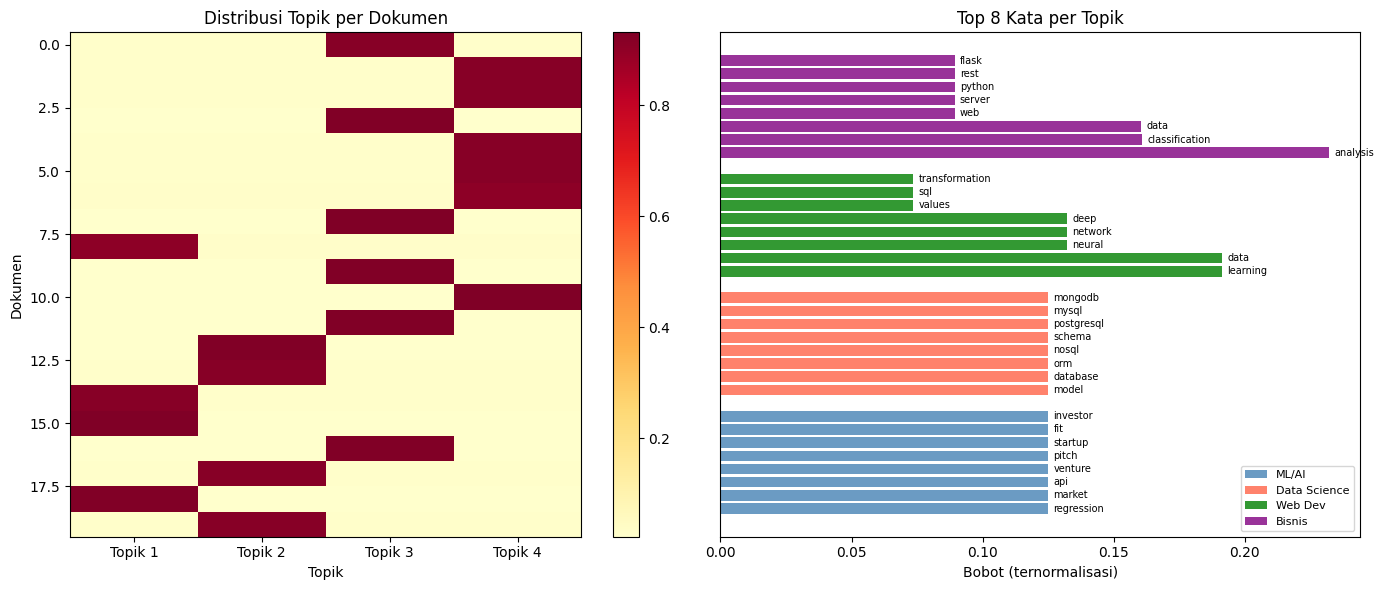

In [22]:
# Visualisasi distribusi topik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap distribusi topik per dokumen
im = axes[0].imshow(doc_topic_dist, aspect="auto", cmap="YlOrRd")
axes[0].set_xlabel("Topik")
axes[0].set_ylabel("Dokumen")
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([f"Topik {i+1}" for i in range(4)])
axes[0].set_title("Distribusi Topik per Dokumen")
plt.colorbar(im, ax=axes[0])

# Bar chart komponen topik (kata teratas per topik)
colors_lda = ["steelblue", "tomato", "green", "purple"]
topic_labels = ["ML/AI", "Data Science", "Web Dev", "Bisnis"]

for topic_idx in range(4):
    top_idx = lda.components_[topic_idx].argsort()[-8:][::-1]
    top_w   = [feature_names_lda[i] for i in top_idx]
    top_v   = lda.components_[topic_idx][top_idx]
    top_v   = top_v / top_v.sum()

    y_pos = np.arange(len(top_w)) + topic_idx * 9
    axes[1].barh(y_pos, top_v, color=colors_lda[topic_idx], alpha=0.8,
                 label=topic_labels[topic_idx])
    for j, (w, v) in enumerate(zip(top_w, top_v)):
        axes[1].text(v + 0.002, y_pos[j], w, va="center", fontsize=7)

axes[1].set_title("Top 8 Kata per Topik")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].set_xlabel("Bobot (ternormalisasi)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()


In [23]:
# Pengaruh n_components (jumlah topik)
print("Perplexity (lebih rendah = model lebih baik) vs n_components:")
print()
for n_topics in [2, 3, 4, 5, 6]:
    lda_n = LatentDirichletAllocation(
        n_components=n_topics, random_state=42,
        max_iter=50, learning_method="batch"
    )
    lda_n.fit(X_lda)
    perplexity = lda_n.perplexity(X_lda)
    print(f"  n_components={n_topics}: perplexity = {perplexity:.2f}")

print()
print("Catatan: perplexity menurun seiring bertambahnya topik,")
print("tapi topik yang terlalu banyak menjadi tidak bermakna.")
print("Pemilihan jumlah topik optimal seringkali membutuhkan inspeksi manual.")


Perplexity (lebih rendah = model lebih baik) vs n_components:

  n_components=2: perplexity = 254.85
  n_components=3: perplexity = 287.05
  n_components=4: perplexity = 291.68
  n_components=5: perplexity = 319.01
  n_components=6: perplexity = 335.11

Catatan: perplexity menurun seiring bertambahnya topik,
tapi topik yang terlalu banyak menjadi tidak bermakna.
Pemilihan jumlah topik optimal seringkali membutuhkan inspeksi manual.


## 7.9 Rangkuman Pipeline Klasifikasi Teks Lengkap


In [24]:
# Pipeline klasifikasi teks yang komprehensif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Bandingkan berbagai classifier dengan tf-idf
text_classifiers = {
    "Logistic Regression": make_pipeline(
        TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True),
        LogisticRegression(max_iter=5000, C=1)
    ),
    "Linear SVC": make_pipeline(
        TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True),
        LinearSVC(max_iter=5000, C=1)
    ),
    "Multinomial NB": make_pipeline(
        CountVectorizer(ngram_range=(1,2), min_df=1),
        MultinomialNB(alpha=0.1)
    ),
}

print("Perbandingan Classifier pada Dataset Ulasan Sentimen:")
print(f"{'Model':<25} {'CV Acc (mean)':>15} {'CV Acc (std)':>15} {'Test Acc':>10}")
print("-" * 68)

for name, pipe in text_classifiers.items():
    cv_sc = cross_val_score(pipe, reviews, labels, cv=5, scoring="accuracy")
    pipe.fit(X_text_tr, y_text_tr)
    test_acc = pipe.score(X_text_te, y_text_te)
    print(f"{name:<25} {cv_sc.mean():>15.4f} {cv_sc.std():>15.4f} {test_acc:>10.4f}")


Perbandingan Classifier pada Dataset Ulasan Sentimen:
Model                       CV Acc (mean)    CV Acc (std)   Test Acc
--------------------------------------------------------------------
Logistic Regression                0.7250          0.1458     0.2000
Linear SVC                         0.7750          0.0935     0.2000
Multinomial NB                     0.7000          0.1275     0.2000


## 7.10 Ringkasan

### Representasi Teks

| Teknik | Kelebihan | Kekurangan |
|--------|-----------|------------|
| CountVectorizer | Sederhana, cepat | Tidak mempertimbangkan kepentingan kata |
| TfidfVectorizer | Down-weight kata umum | Masih tidak mempertimbangkan urutan |
| n-Grams | Tangkap konteks lokal | Vocabulary sangat besar |

### Panduan Penggunaan

**CountVectorizer vs TfidfVectorizer:**
- TfidfVectorizer hampir selalu lebih baik dari CountVectorizer
- Gunakan `sublinear_tf=True` untuk meredam efek kata yang sangat sering

**n-Grams:**
- `ngram_range=(1,2)` adalah pilihan yang baik untuk dikombinasikan
- Jarang butuh lebih dari trigram

**Stopwords:**
- Membantu untuk dataset kecil atau vocabulary besar
- Pada beberapa kasus (sentimen dengan negasi), bisa merugikan

**Topic Modeling (LDA):**
- Berguna untuk eksplorasi dataset besar tanpa label
- Jumlah topik harus ditentukan manual dan membutuhkan interpretasi
- Gunakan perplexity sebagai panduan kasar, inspeksi topik secara manual

### Pipeline yang Direkomendasikan

```python
pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=5000, C=1)
)
```

Ini adalah baseline yang kuat untuk hampir semua tugas klasifikasi teks.
